In [ ]:
! pip install -q kaggle

In [ ]:
# prompt: fix above problem

from google.colab import files

files.upload()

# Create a directory for Kaggle configuration files if it doesn't exist
!mkdir -p ~/.kaggle

!cp kaggle.json ~/.kaggle/
# Make the kaggle.json file executable (required by the Kaggle API)
!chmod 600 ~/.kaggle/kaggle.json

#! mkdir ~/.kaggle

!cp kaggle.json ~/.kaggle/
! chmod 600 ~/.kaggle/kaggle.json

Saving kaggle.json to kaggle.json


In [ ]:
!kaggle competitions download -c solar-energy-forecasting

  0% 0.00/456k [00:00<?, ?B/s]
100% 456k/456k [00:00<00:00, 946MB/s]


In [ ]:
! unzip solar-energy-forecasting.zip

Archive:  solar-energy-forecasting.zip
  inflating: Sample-submission.csv   
  inflating: Test.csv                
  inflating: Train/Train/2020-4.csv  
  inflating: Train/Train/2021-1.csv  
  inflating: Train/Train/2021-2.csv  
  inflating: Train/Train/2021-3.csv  
  inflating: Train/Train/2021-4.csv  
  inflating: Train/Train/2022-1.csv  
  inflating: Train/Train/2022-2.csv  
  inflating: Train/Train/2022-3.csv  
  inflating: Train/Train/2022-4.csv  
  inflating: Train/Train/2023-1.csv  
  inflating: Train/Train/2023-2.csv  


In [ ]:
import pandas as pd
import os

os.listdir('Train/Train/')

['2022-2.csv',
 '2021-3.csv',
 '2023-1.csv',
 '2020-4.csv',
 '2022-3.csv',
 '2023-2.csv',
 '2021-4.csv',
 '2022-1.csv',
 '2021-1.csv',
 '2022-4.csv',
 '2021-2.csv']

In [ ]:
train_df = pd.concat([pd.read_csv('Train/Train/'+file) for file in sorted(os.listdir('Train/Train/'))])
train_df

,Time,System Production (W)
0,10/01/2020 00:00,0.0
1,10/01/2020 00:15,0.0
2,10/01/2020 00:30,0.0
3,10/01/2020 00:45,0.0
4,10/01/2020 01:00,0.0
...,...,...
8731,06/30/2023 22:45,0.0
8732,06/30/2023 23:00,0.0
8733,06/30/2023 23:15,0.0
8734,06/30/2023 23:30,0.0


In [ ]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 96288 entries, 0 to 8735
Data columns (total 2 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Time                   96288 non-null  object 
 1   System Production (W)  96288 non-null  float64
dtypes: float64(1), object(1)
memory usage: 4.2+ MB


In [ ]:
train_df['Time'] = pd.to_datetime(train_df['Time'])

array([[<Axes: title={'center': 'System Production (W)'}>]], dtype=object)

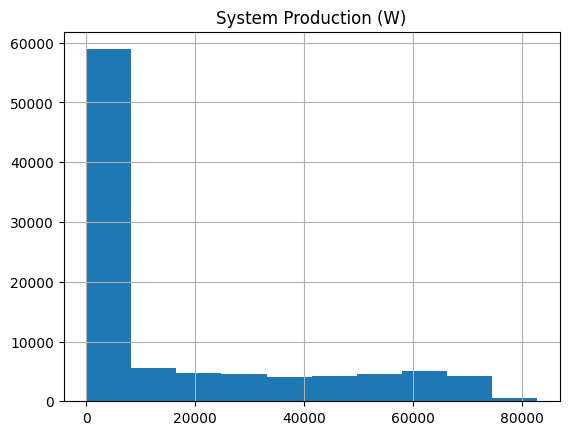

In [ ]:
train_df.set_index('Time').hist()

array([[<Axes: title={'center': 'System Production (W)'}>]], dtype=object)

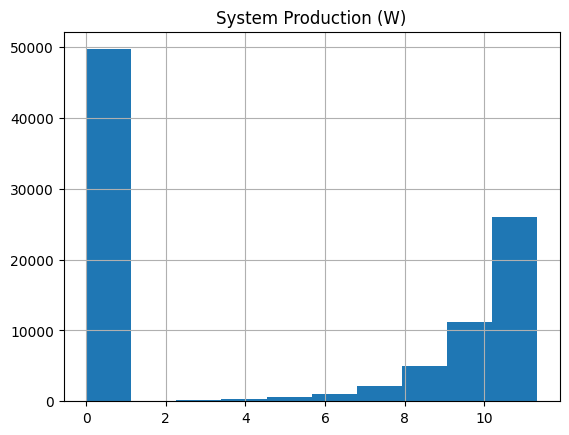

In [ ]:
import numpy as np
train_df['System Production (W)'] = np.log1p(train_df['System Production (W)'])
train_df.set_index('Time').hist()

In [ ]:
train_df.sort_values('Time', inplace=True)
train_df

,Time,System Production (W)
0,2020-10-01 00:00:00,0.0
1,2020-10-01 00:15:00,0.0
2,2020-10-01 00:30:00,0.0
3,2020-10-01 00:45:00,0.0
4,2020-10-01 01:00:00,0.0
...,...,...
8731,2023-06-30 22:45:00,0.0
8732,2023-06-30 23:00:00,0.0
8733,2023-06-30 23:15:00,0.0
8734,2023-06-30 23:30:00,0.0


In [ ]:
train_df["quarter"] = train_df["Time"].dt.quarter
train_df["quarter_sin"] = np.sin(2 * np.pi * train_df["quarter"] / 4)
train_df["quarter_cos"] = np.cos(2 * np.pi * train_df["quarter"] / 4)

train_df["hour"] = train_df["Time"].dt.hour
train_df["hour_sin"] = np.sin(2 * np.pi * train_df["hour"] / 24)
train_df["hour_cos"] = np.cos(2 * np.pi * train_df["hour"] / 24)

train_df["minute"] = train_df["Time"].dt.minute
train_df["minute_sin"] = np.sin(2 * np.pi * train_df["minute"] / 60)
train_df["minute_cos"] = np.cos(2 * np.pi * train_df["minute"] / 60)

train_df["day_of_year"] = train_df["Time"].dt.dayofyear
train_df["dayofyear_sin"] = np.sin(2 * np.pi * train_df["day_of_year"] / 366)
train_df["dayofyear_cos"] = np.cos(2 * np.pi * train_df["day_of_year"] / 366)

train_df["week_of_year"] = train_df["Time"].dt.isocalendar().week
train_df["week_sin"] = np.sin(2 * np.pi * train_df["week_of_year"] / 52)
train_df["week_cos"] = np.cos(2 * np.pi * train_df["week_of_year"] / 52)

# Day of month (1–31)
train_df["day_of_month"] = train_df["Time"].dt.day
train_df["dayofmonth_sin"] = np.sin(2 * np.pi * train_df["day_of_month"] / 31)
train_df["dayofmonth_cos"] = np.cos(2 * np.pi * train_df["day_of_month"] / 31)

train_df["month_of_year"] = train_df["Time"].dt.month
train_df["monthofyear_sin"] = np.sin(2 * np.pi * train_df["month_of_year"] / 12)
train_df["monthofyear_cos"] = np.cos(2 * np.pi * train_df["month_of_year"] / 12)

# Weekday (0=Mon, 6=Sun) and is_weekend
train_df["weekday"] = train_df["Time"].dt.weekday
train_df["weekday_sin"] = np.sin(2 * np.pi * train_df["weekday"] / 6)
train_df["weekday_cos"] = np.cos(2 * np.pi * train_df["weekday"] / 6)
train_df["is_weekend"] = train_df["weekday"].isin([5, 6]).astype(np.uint8)
train_df

,Time,System Production (W),quarter,quarter_sin,quarter_cos,hour,hour_sin,hour_cos,minute,minute_sin,...,day_of_month,dayofmonth_sin,dayofmonth_cos,month_of_year,monthofyear_sin,monthofyear_cos,weekday,weekday_sin,weekday_cos,is_weekend
0,2020-10-01 00:00:00,0.0,4,-2.449294e-16,1.0,0,0.000000,1.000000,0,0.000000e+00,...,1,0.201299,0.97953,10,-8.660254e-01,0.5,3,1.224647e-16,-1.0,0
1,2020-10-01 00:15:00,0.0,4,-2.449294e-16,1.0,0,0.000000,1.000000,15,1.000000e+00,...,1,0.201299,0.97953,10,-8.660254e-01,0.5,3,1.224647e-16,-1.0,0
2,2020-10-01 00:30:00,0.0,4,-2.449294e-16,1.0,0,0.000000,1.000000,30,5.665539e-16,...,1,0.201299,0.97953,10,-8.660254e-01,0.5,3,1.224647e-16,-1.0,0
3,2020-10-01 00:45:00,0.0,4,-2.449294e-16,1.0,0,0.000000,1.000000,45,-1.000000e+00,...,1,0.201299,0.97953,10,-8.660254e-01,0.5,3,1.224647e-16,-1.0,0
4,2020-10-01 01:00:00,0.0,4,-2.449294e-16,1.0,1,0.258819,0.965926,0,0.000000e+00,...,1,0.201299,0.97953,10,-8.660254e-01,0.5,3,1.224647e-16,-1.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8731,2023-06-30 22:45:00,0.0,2,1.224647e-16,-1.0,22,-0.500000,0.866025,45,-1.000000e+00,...,30,-0.201299,0.97953,6,1.224647e-16,-1.0,4,-8.660254e-01,-0.5,0
8732,2023-06-30 23:00:00,0.0,2,1.224647e-16,-1.0,23,-0.258819,0.965926,0,0.000000e+00,...,30,-0.201299,0.97953,6,1.224647e-16,-1.0,4,-8.660254e-01,-0.5,0
8733,2023-06-30 23:15:00,0.0,2,1.224647e-16,-1.0,23,-0.258819,0.965926,15,1.000000e+00,...,30,-0.201299,0.97953,6,1.224647e-16,-1.0,4,-8.660254e-01,-0.5,0
8734,2023-06-30 23:30:00,0.0,2,1.224647e-16,-1.0,23,-0.258819,0.965926,30,5.665539e-16,...,30,-0.201299,0.97953,6,1.224647e-16,-1.0,4,-8.660254e-01,-0.5,0


In [ ]:
test_df = pd.read_csv('Test.csv')
test_df

,Time,System Production (W)
0,09/16/2023 09:45,NaN
1,12/28/2023 12:15,NaN
2,3/6/2024 9:00,NaN
3,7/1/2023 11:15,NaN
4,7/3/2023 8:30,NaN
...,...,...
3341,06/13/2024 16:30,NaN
3342,12/26/2023 06:30,NaN
3343,10/15/2023 15:45,NaN
3344,12/2/2023 12:15,NaN


In [ ]:
test_df['Time'] = pd.to_datetime(test_df['Time'])

In [ ]:
test_df["quarter"] = test_df["Time"].dt.quarter
test_df["quarter_sin"] = np.sin(2 * np.pi * test_df["quarter"] / 4)
test_df["quarter_cos"] = np.cos(2 * np.pi * test_df["quarter"] / 4)

test_df["hour"] = test_df["Time"].dt.hour
test_df["hour_sin"] = np.sin(2 * np.pi * test_df["hour"] / 24)
test_df["hour_cos"] = np.cos(2 * np.pi * test_df["hour"] / 24)

test_df["minute"] = test_df["Time"].dt.minute
test_df["minute_sin"] = np.sin(2 * np.pi * test_df["minute"] / 60)
test_df["minute_cos"] = np.cos(2 * np.pi * test_df["minute"] / 60)

test_df["day_of_year"] = test_df["Time"].dt.dayofyear
test_df["dayofyear_sin"] = np.sin(2 * np.pi * test_df["day_of_year"] / 366)
test_df["dayofyear_cos"] = np.cos(2 * np.pi * test_df["day_of_year"] / 366)

test_df["week_of_year"] = test_df["Time"].dt.isocalendar().week
test_df["week_sin"] = np.sin(2 * np.pi * test_df["week_of_year"] / 52)
test_df["week_cos"] = np.cos(2 * np.pi * test_df["week_of_year"] / 52)

# Day of month (1–31)
test_df["day_of_month"] = test_df["Time"].dt.day
test_df["dayofmonth_sin"] = np.sin(2 * np.pi * test_df["day_of_month"] / 31)
test_df["dayofmonth_cos"] = np.cos(2 * np.pi * test_df["day_of_month"] / 31)

test_df["month_of_year"] = test_df["Time"].dt.month
test_df["monthofyear_sin"] = np.sin(2 * np.pi * test_df["month_of_year"] / 12)
test_df["monthofyear_cos"] = np.cos(2 * np.pi * test_df["month_of_year"] / 12)

# Weekday (0=Mon, 6=Sun) and is_weekend
test_df["weekday"] = test_df["Time"].dt.weekday
test_df["weekday_sin"] = np.sin(2 * np.pi * test_df["weekday"] / 6)
test_df["weekday_cos"] = np.cos(2 * np.pi * test_df["weekday"] / 6)
test_df["is_weekend"] = test_df["weekday"].isin([5, 6]).astype(np.uint8)
test_df

,Time,System Production (W),quarter,quarter_sin,quarter_cos,hour,hour_sin,hour_cos,minute,minute_sin,...,day_of_month,dayofmonth_sin,dayofmonth_cos,month_of_year,monthofyear_sin,monthofyear_cos,weekday,weekday_sin,weekday_cos,is_weekend
0,2023-09-16 09:45:00,NaN,3,-1.000000e+00,-1.836970e-16,9,7.071068e-01,-7.071068e-01,45,-1.000000e+00,...,16,-0.101168,-0.994869,9,-1.000000e+00,-1.836970e-16,5,-8.660254e-01,0.5,1
1,2023-12-28 12:15:00,NaN,4,-2.449294e-16,1.000000e+00,12,1.224647e-16,-1.000000e+00,15,1.000000e+00,...,28,-0.571268,0.820763,12,-2.449294e-16,1.000000e+00,3,1.224647e-16,-1.0,0
2,2024-03-06 09:00:00,NaN,1,1.000000e+00,6.123234e-17,9,7.071068e-01,-7.071068e-01,0,0.000000e+00,...,6,0.937752,0.347305,3,1.000000e+00,6.123234e-17,2,8.660254e-01,-0.5,0
3,2023-07-01 11:15:00,NaN,3,-1.000000e+00,-1.836970e-16,11,2.588190e-01,-9.659258e-01,15,1.000000e+00,...,1,0.201299,0.979530,7,-5.000000e-01,-8.660254e-01,5,-8.660254e-01,0.5,1
4,2023-07-03 08:30:00,NaN,3,-1.000000e+00,-1.836970e-16,8,8.660254e-01,-5.000000e-01,30,5.665539e-16,...,3,0.571268,0.820763,7,-5.000000e-01,-8.660254e-01,0,0.000000e+00,1.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3341,2024-06-13 16:30:00,NaN,2,1.224647e-16,-1.000000e+00,16,-8.660254e-01,-5.000000e-01,30,5.665539e-16,...,13,0.485302,-0.874347,6,1.224647e-16,-1.000000e+00,3,1.224647e-16,-1.0,0
3342,2023-12-26 06:30:00,NaN,4,-2.449294e-16,1.000000e+00,6,1.000000e+00,6.123234e-17,30,5.665539e-16,...,26,-0.848644,0.528964,12,-2.449294e-16,1.000000e+00,1,8.660254e-01,0.5,0
3343,2023-10-15 15:45:00,NaN,4,-2.449294e-16,1.000000e+00,15,-7.071068e-01,-7.071068e-01,45,-1.000000e+00,...,15,0.101168,-0.994869,10,-8.660254e-01,5.000000e-01,6,-2.449294e-16,1.0,1
3344,2023-12-02 12:15:00,NaN,4,-2.449294e-16,1.000000e+00,12,1.224647e-16,-1.000000e+00,15,1.000000e+00,...,2,0.394356,0.918958,12,-2.449294e-16,1.000000e+00,5,-8.660254e-01,0.5,1


In [ ]:
test_df.columns

Index(['Time', 'System Production (W)', 'quarter', 'quarter_sin',
       'quarter_cos', 'hour', 'hour_sin', 'hour_cos', 'minute', 'minute_sin',
       'minute_cos', 'day_of_year', 'dayofyear_sin', 'dayofyear_cos',
       'week_of_year', 'week_sin', 'week_cos', 'day_of_month',
       'dayofmonth_sin', 'dayofmonth_cos', 'month_of_year', 'monthofyear_sin',
       'monthofyear_cos', 'weekday', 'weekday_sin', 'weekday_cos',
       'is_weekend'],
      dtype='object')

In [ ]:
features = ['quarter', 'quarter_sin',
       'quarter_cos', 'hour', 'hour_sin', 'hour_cos', 'minute', 'minute_sin',
       'minute_cos', 'day_of_year', 'dayofyear_sin', 'dayofyear_cos',
       'week_of_year', 'week_sin', 'week_cos', 'day_of_month',
       'dayofmonth_sin', 'dayofmonth_cos', 'month_of_year', 'monthofyear_sin',
       'monthofyear_cos', 'weekday', 'weekday_sin', 'weekday_cos',
       'is_weekend']

In [ ]:
target = 'System Production (W)'

In [ ]:
from sklearn.ensemble import RandomForestRegressor

RandomForestRegressor?

In [ ]:
# starter pack: n_estimators=100, max_depth=10

In [ ]:
regressor = RandomForestRegressor(
    n_estimators=100, max_depth=10, random_state=0, oob_score=True, n_jobs=-1
)

regressor.fit(train_df[features], train_df[target])
print('OOB Score (R^2): ', regressor.oob_score_)

OOB Score (R^2):  0.9745093653104786


In [ ]:
# catboost (class / time series -> regressor)

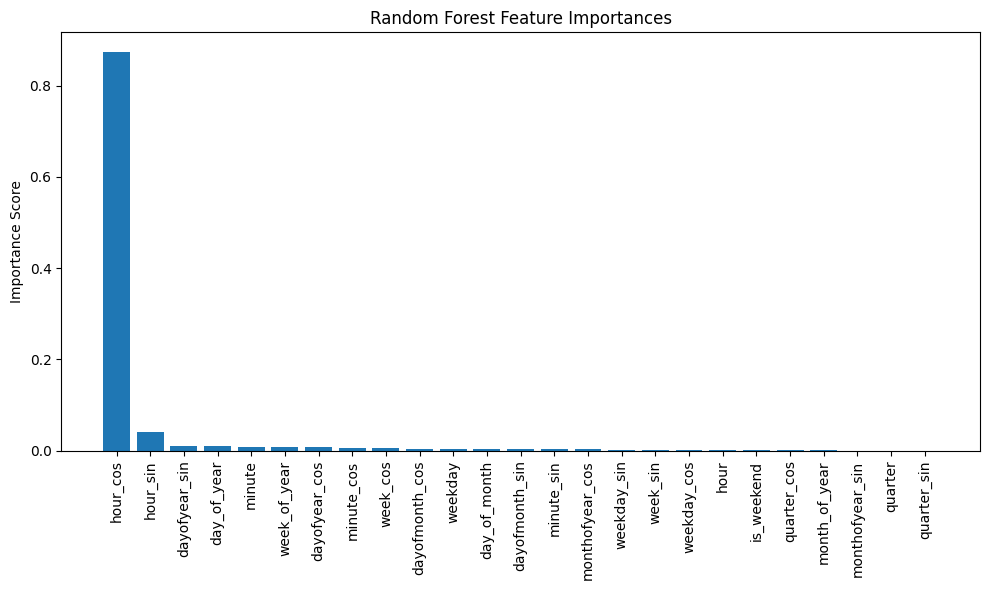

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Get feature importances
importances = regressor.feature_importances_

# Create DataFrame for visualization
feat_importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# Plot
plt.figure(figsize=(10, 6))
plt.bar(feat_importance_df['Feature'], feat_importance_df['Importance'])
plt.xticks(rotation=90)
plt.title("Random Forest Feature Importances")
plt.ylabel("Importance Score")
plt.tight_layout()
plt.show()

In [ ]:
! pip install -q optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 395.9/395.9 kB 27.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 242.7/242.7 kB 23.4 MB/s eta 0:00:00


In [ ]:
ไม่ต้องรันเพราะเรารู้อยู่แล้วว่า randomforest ปรับเท่าไรเก่ง

import optuna
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import make_scorer, r2_score
import numpy as np

# Objective function for Optuna
def objective(trial):
    # Suggest hyperparameters
    n_estimators = trial.suggest_int("n_estimators", 50, 300)
    max_depth = trial.suggest_int("max_depth", 3, 30)
    max_features = trial.suggest_categorical("max_features", ["sqrt", "log2"])

    # Define the model with suggested hyperparameters
    model = RandomForestRegressor(
        n_estimators=n_estimators,
        max_depth=max_depth,
        max_features=max_features,
        oob_score=True,
        bootstrap=True,
        random_state=0,
        n_jobs=-1,
    )

    # Use cross-validation to evaluate performance
    scores = cross_val_score(
        model,
        train_df[features],
        train_df[target],
        cv=5,
        scoring='r2',
        n_jobs=-1
    )

    return scores.mean()

# Run the optimization
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=50, timeout=600)  # You can increase n_trials for better results

# Best parameters and score
print("Best trial:")
print("  Value (R^2):", study.best_trial.value)
print("  Params:", study.best_trial.params)

[I 2025-07-02 18:02:55,743] A new study created in memory with name: no-name-3aac518d-834a-4e9f-8862-ba93aa1ce9b7
[W 2025-07-02 18:02:59,576] Trial 0 failed with parameters: {'n_estimators': 172, 'max_depth': 17, 'max_features': 'sqrt'} because of the following error: KeyboardInterrupt().
Traceback (most recent call last):
  File "/usr/local/lib/python3.11/dist-packages/optuna/study/_optimize.py", line 201, in _run_trial
    value_or_values = func(trial)
                      ^^^^^^^^^^^
  File "/tmp/ipython-input-31-1594297366.py", line 26, in objective
    scores = cross_val_score(
             ^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/sklearn/utils/_param_validation.py", line 216, in wrapper
    return func(*args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_validation.py", line 684, in cross_val_score
    cv_results = cross_validate(
                 ^^^^^^^^^^^^^^^
  File "/usr/local/lib/

KeyboardInterrupt: 

In [ ]:
prediction = regressor.predict(test_df[features])
prediction

array([10.43831185, 10.75152171, 10.50115136, ...,  8.7726773 ,
       10.79471569, 10.50025937])

In [ ]:
submission = pd.read_csv('Sample-submission.csv')
submission

,Time,System Production (W)
0,09/16/2023 09:45,62059.3281
1,12/28/2023 12:15,58862.0000
2,3/6/2024 9:00,48442.0000
3,7/1/2023 11:15,NaN
4,7/3/2023 8:30,NaN
...,...,...
3341,06/13/2024 16:30,NaN
3342,12/26/2023 06:30,NaN
3343,10/15/2023 15:45,NaN
3344,12/2/2023 12:15,NaN


In [ ]:
# submission['System Production (W)'][3:] = np.expm1(prediction)
submission.loc[3:,'System Production (W)'] = np.expm1(prediction[3:])
submission

,Time,System Production (W)
0,09/16/2023 09:45,62059.328100
1,12/28/2023 12:15,58862.000000
2,3/6/2024 9:00,48442.000000
3,7/1/2023 11:15,55753.603412
4,7/3/2023 8:30,31271.967209
...,...,...
3341,06/13/2024 16:30,14688.266411
3342,12/26/2023 06:30,3.904514
3343,10/15/2023 15:45,6454.432499
3344,12/2/2023 12:15,48761.443229


In [ ]:
submission.to_csv('submission.csv', index=False)

In [ ]:
!kaggle competitions submit -c solar-energy-forecasting -f submission.csv -m "Message"

100% 113k/113k [00:01<00:00, 113kB/s]
Successfully submitted to Solar Energy Forecasting

In [ ]:
! pip install -q optuna